Colab de referência: https://colab.research.google.com/drive/1s0wK-XDQOdUubutjqhJVQL-6q6jKAfy9

#### Dados balanceados x não balanceados

**Dados balanceados:** quando o número de classes possuem similaridade no número de registros;

**Dados não balanceados**: quando o número de registros de uma classe é maior ou menor do que outra.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# carregar o dataset titanic
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
titanic = pd.read_csv(url)
# titanic.head()

# filtrar colunas relevantes e remover valores ausentes
titanic = titanic[['survived', 'pclass', 'age', 'sibsp', 'fare']]

# verificar quantos registros
print(f"Antes: {titanic.shape[0]}")

# remover valores ausentes
titanic = titanic.dropna()
print(f"Depois: {titanic.shape[0]}")

# dividir em características (features) e alvo (target)
X = titanic.drop(columns=['survived'])
y = titanic['survived']

# dividir em 70% de treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Quantidade de valores únicos para cada classe da coluna alvo
y.value_counts()

Antes: 891
Depois: 714


survived
0    424
1    290
Name: count, dtype: int64

In [17]:
# filtrando um valor específico
survived = titanic.loc[titanic['survived'] == 1, 'survived']
print(f"Sobreviventes: {len(survived)}")

unsurvived = titanic.loc[titanic['survived'] == 0, 'survived']
# print(f"Não sobreviventes: {titanic.shape[0]-len(survived)}")
print(f"Não sobreviventes: {len(unsurvived)}")

Sobreviventes: 290
Não sobreviventes: 424


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def treina_modelo (X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # avaliar no conjunto de validação
    y_val_pred = model.predict(X_val)
    y_val_acc = accuracy_score(y_val, y_val_pred)
    y_val_acc = y_val_acc * 100
    print(f"Acurácia na validação: {y_val_acc:.2f}%")

    # avaliar no conjunto de teste
    y_test_pred = model.predict(X_test)
    y_test_acc = accuracy_score(y_test, y_test_pred)
    y_test_acc = y_test_acc * 100
    print(f"Acurácia no teste: {y_test_acc:.2f}%")

#### Treinar o modelo

##### *Oversampling* com SMOTE

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(y_train_smote.value_counts())

survived
0    298
1    298
Name: count, dtype: int64


#### Comparação de acurácia entre modelo balanceado com SMOTE e modelo desbalanceado

In [20]:
print("Modelo treinado ignorando o desbalancemanento")
treina_modelo(X_train, y_train, X_test, y_test)

print("\n************************************\n")
print("Modelo treinado após o SMOTE")
treina_modelo(X_train_smote, y_train_smote, X_test, y_test)

Modelo treinado ignorando o desbalancemanento
Acurácia na validação: 70.70%
Acurácia no teste: 70.70%

************************************

Modelo treinado após o SMOTE
Acurácia na validação: 73.49%
Acurácia no teste: 73.49%


#### *Undersampling* com RandomUnderSampler


In [21]:
# cria o modelo undersampler através da classe RandomUnderSampler.
# novamente o random_state é utilizado para que os dados sejam replicáveis
undersampler = RandomUnderSampler(random_state=0)
# Eliminam-se dados com base no X_train e y_train utilizando o RandomUnderSampler.
# Os novos dados são guardados nas variáveis X_train_under e y_train_under
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Visualizar distribuição da classe target após undersampling
print(y_train_under.value_counts())

survived
0    201
1    201
Name: count, dtype: int64


In [22]:
# Exercício Resolvido
# Comparação da acurácia com o balancelamento

print("Modelo treinado ignorando o desbalancemanento")
treina_modelo(X_train, y_train, X_test, y_test)

print("\n************************************\n")
print("Modelo treinado após o Undersampling")
treina_modelo(X_train_under, y_train_under, X_test, y_test)

Modelo treinado ignorando o desbalancemanento
Acurácia na validação: 70.70%
Acurácia no teste: 70.70%

************************************

Modelo treinado após o Undersampling
Acurácia na validação: 72.56%
Acurácia no teste: 72.56%


#### Underfitting
Underfitting ocorre quando um modelo é muito simples para capturar a complexidade dos dados

In [23]:
# Importação das bibliotecas que serão utilizadas
import matplotlib.pyplot as plt
import numpy as np

# Define o modelo ideal como sendo uma função quadrática
def true_function(x):
    return x**2

# Gerar dados sintéticos
# Define-se um gerador aleatório que seja reprodutível, é semelhante ao parÂmetro random_state visto anteriormente
np.random.seed(22)

# Geram-se 10 valores aleatórios entre -2 e 2
x = np.sort(np.random.rand(10) * 4 - 2)  # random values between -2 and 2

# Para cada valor gerado anteriormente, aplica a função verdade `true_function(x)` para obter o valor de y
# adiciona-se um ruído com `np.random.randn(10)` para que o valor não caia sempre sobre o próprio modelo
y = true_function(x) + np.random.randn(10)

# Criam-se os dados de teste
# x_fit são 100 valores igualmente espaçados entre -2 e 2
x_fit = np.linspace(-2, 2, 100)
# y_true é o resultado do modelo ideal para os dados de x_fit
y_true = true_function(x_fit)

In [24]:
from sklearn.linear_model import LinearRegression

# Cria o modelo de regressão linear
model_underfit = LinearRegression()
# Treina o modelo com dados de treino
model_underfit.fit(x.reshape(-1, 1), y)
# Obtem-se os resultados do modelo através do teste dos valores de x_fit
y_underfit = model_underfit.predict(x_fit.reshape(-1, 1))

#### Overfitting

Overfitting ocorre quando um modelo é muito complexo e captura o ruído dos dados de treino.


In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define o grau do modelo polinomial
degree = 4

# Cria o modelo de regresão polinomial
model_overfit = make_pipeline(PolynomialFeatures(degree), LinearRegression())
# Treina o modelo com dados de treino
model_overfit.fit(x.reshape(-1, 1), y)
# Obtem-se os resultados do modelo através do teste dos valores de x_fit
y_overfit = model_overfit.predict(x_fit.reshape(-1, 1))

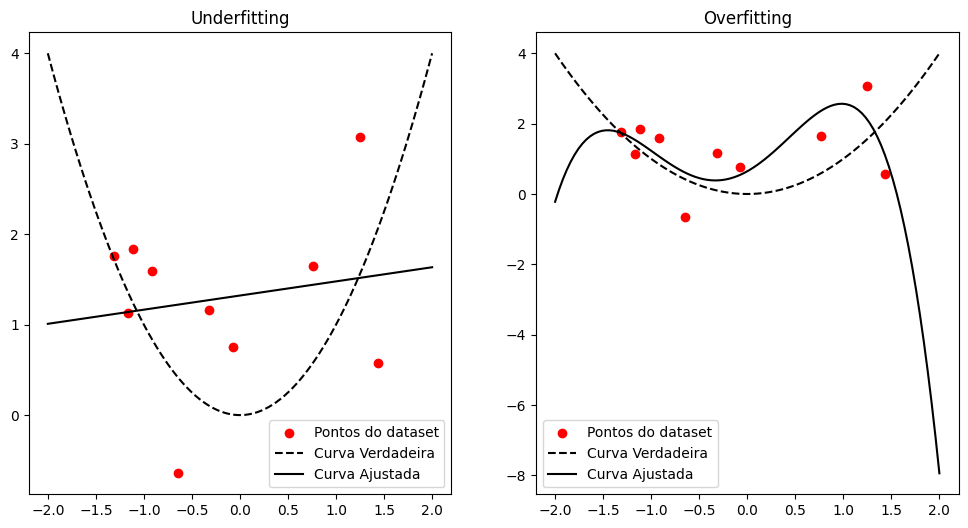

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Underfitting plot
axs[0].scatter(x, y, color='red', label='Pontos do dataset')
axs[0].plot(x_fit, y_true, 'k--', label='Curva Verdadeira')
axs[0].plot(x_fit, y_underfit, 'k-', label='Curva Ajustada')
axs[0].set_title('Underfitting')
axs[0].legend()

# Overfitting plot
axs[1].scatter(x, y, color='red', label='Pontos do dataset')
axs[1].plot(x_fit, y_true, 'k--', label='Curva Verdadeira')
axs[1].plot(x_fit, y_overfit, 'k-', label='Curva Ajustada')
axs[1].set_title('Overfitting')
axs[1].legend()

plt.show()

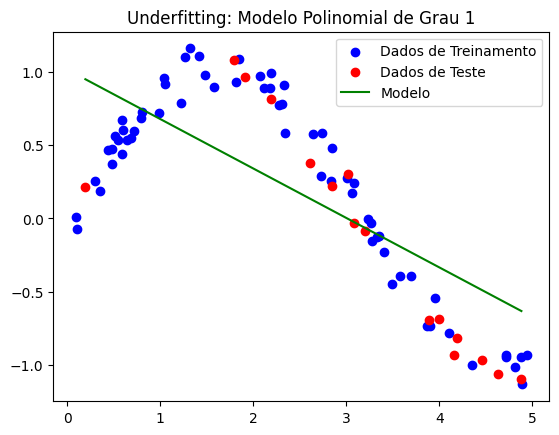

Underfitting: Modelo Polinomial de Grau 1 - Treino - MSE: 0.1868, R^2: 0.5585
Underfitting: Modelo Polinomial de Grau 1 - Teste - MSE: 0.2045, R^2: 0.6138


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Gerar dados sintéticos
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # Adiciona ruído

# Dividir os dados em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Ordena os dados para facilitar a plotagem
z = sorted(zip(X_test,y_test))
X_test,y_test = zip(*z)

# Função para plotar os resultados
def plot_results(X_train, y_train, X_test, y_test, model, X_poly, title):
    plt.scatter(X_train, y_train, color='blue', label='Dados de Treinamento')
    plt.scatter(X_test, y_test, color='red', label='Dados de Teste')
    plt.plot(X_test, model.predict(X_poly), color='green', label='Modelo')
    plt.title(title)
    plt.legend()
    plt.show()

# Função para calcular e imprimir as métricas
def print_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MSE: {mse:.4f}, R^2: {r2:.4f}")

    # Criando Features Polinomiais para Underfitting
poly_features_underfit = PolynomialFeatures(degree=1)  # Grau 1 para underfitting
X_poly_train_underfit = poly_features_underfit.fit_transform(X_train)
X_poly_test_underfit = poly_features_underfit.transform(X_test)

# Treinando o Modelo de Underfitting
poly_reg_underfit = LinearRegression()
poly_reg_underfit.fit(X_poly_train_underfit, y_train)
plot_results(X_train, y_train, X_test, y_test, poly_reg_underfit, X_poly_test_underfit, "Underfitting: Modelo Polinomial de Grau 1")

# Plotando os Resultados e Imprimindo Métricas
print_metrics(y_train, poly_reg_underfit.predict(X_poly_train_underfit), "Underfitting: Modelo Polinomial de Grau 1 - Treino")
print_metrics(y_test, poly_reg_underfit.predict(X_poly_test_underfit), "Underfitting: Modelo Polinomial de Grau 1 - Teste")

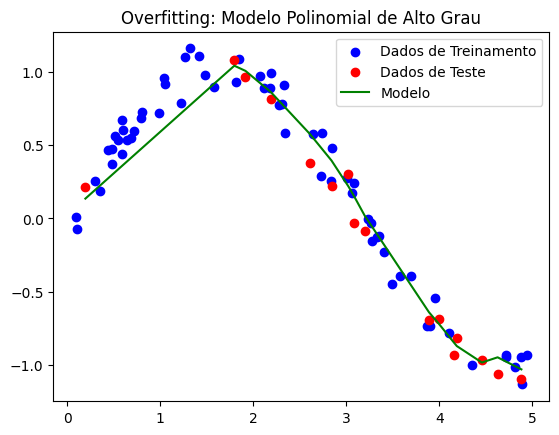

Overfitting: Modelo Polinomial de Alto Grau - Treino - MSE: 0.0078, R^2: 0.9815
Overfitting: Modelo Polinomial de Alto Grau - Teste - MSE: 0.0101, R^2: 0.9809


In [28]:
# Criando Features Polinomiais para overfitting
poly_features_overfit = PolynomialFeatures(degree=15)  # Grau alto para overfitting
X_poly_train_overfit = poly_features_overfit.fit_transform(X_train)
X_poly_test_overfit = poly_features_overfit.transform(X_test)

# Treinando o Modelo de overfitting
poly_reg_overfit = LinearRegression()
poly_reg_overfit.fit(X_poly_train_overfit, y_train)
plot_results(X_train, y_train, X_test, y_test, poly_reg_overfit, X_poly_test_overfit, "Overfitting: Modelo Polinomial de Alto Grau")

# Plotando os Resultados e Imprimindo Métricas
print_metrics(y_train, poly_reg_overfit.predict(X_poly_train_overfit), "Overfitting: Modelo Polinomial de Alto Grau - Treino")
print_metrics(y_test, poly_reg_overfit.predict(X_poly_test_overfit), "Overfitting: Modelo Polinomial de Alto Grau - Teste")

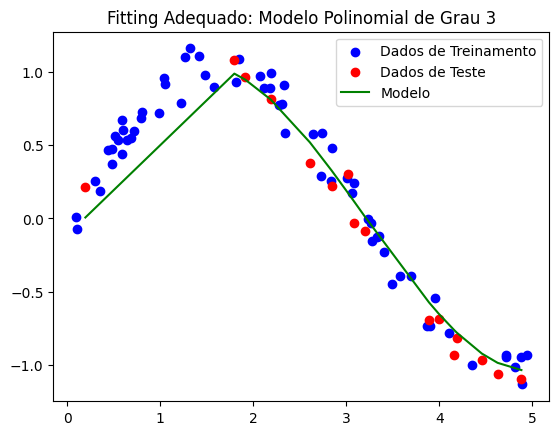

Fitting Adequado: Modelo Polinomial de Grau 3 - Treino - MSE: 0.0112, R^2: 0.9734
Fitting Adequado: Modelo Polinomial de Grau 3 - Teste - MSE: 0.0117, R^2: 0.9779


In [29]:
poly_features_fit = PolynomialFeatures(degree=3)  # Grau intermediário para fitting adequado
X_poly_train_fit = poly_features_fit.fit_transform(X_train)
X_poly_test_fit = poly_features_fit.transform(X_test)

poly_reg_fit = LinearRegression()
poly_reg_fit.fit(X_poly_train_fit, y_train)
plot_results(X_train, y_train, X_test, y_test, poly_reg_fit, X_poly_test_fit, "Fitting Adequado: Modelo Polinomial de Grau 3")

print_metrics(y_train, poly_reg_fit.predict(X_poly_train_fit), "Fitting Adequado: Modelo Polinomial de Grau 3 - Treino")
print_metrics(y_test, poly_reg_fit.predict(X_poly_test_fit), "Fitting Adequado: Modelo Polinomial de Grau 3 - Teste")

#### **O que observar?**

Observe as metricas MSE e $R^2$ entre os conjuntos de Treino e Teste em cada modelo.

- **Underfitting**: valores elevado de MSE quando comparados com os modelos adequado e overfitting. Isso indica que os outros modelo representam melhor. Isso já era esperado uma vez que o modelo linear (grau 1) é o mais simples possível.
- **Overfitting**: grande diferença no MSE quando comparado o dataset de Treino e Teste. Nesse caso, o modelo acaba se ajustando ao treino e é incapaz de generalizar para os novos dados (Teste).
- **Adequado**: Não possui o melhor resultado de MSE no treino, mas obteve o melhor MSE no Teste. Também não há grandes diferenças de MSE entre o conjunto de Treino e Teste, indicando que o modelo conseguiu generalizar e manteve o mesmo acerto tanto para os dados que ele conhecia (Treino) como para os que ele nunca viu (Teste).